In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [196]:
df = pd.read_csv('cleaned_file.csv')
df

,id,brand,price,destination,hand_luggage,checked_baggage,start_hour,end_hour,trip_mins,is_holiday,days_left
0,PQC0002,Bamboo Airways,1245267,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,60,2,1
1,PQC0323,Vietravel Airlines,1224930,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,60,2,1
2,PQC0292,Vietnam Airlines,1535463,Phú Quốc (PQC)\nSân bay Phú Quốc,12,23,Evening,Evening,60,2,1
3,PQC0109,VietJet Air,1567000,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Afternoon,Evening,60,2,1
4,PQC0132,VietJet Air,1567000,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,65,2,1
...,...,...,...,...,...,...,...,...,...,...,...
45492,CXR0244,Vietnam Airlines,1505493,Nha Trang (CXR)\nSân bay Cam Ranh,12,23,Morning,Morning,75,0,9
45493,CXR0245,Vietnam Airlines,1997001,Nha Trang (CXR)\nSân bay Cam Ranh,12,23,Morning,Afternoon,65,2,18
45494,CXR0246,Vietnam Airlines,1379619,Nha Trang (CXR)\nSân bay Cam Ranh,12,23,Morning,Afternoon,65,2,20
45495,CXR0247,Vietnam Airlines,1152900,Nha Trang (CXR)\nSân bay Cam Ranh,12,23,Morning,Afternoon,65,0,20


# EDA

In [197]:
df.describe()

,price,hand_luggage,checked_baggage,trip_mins,is_holiday,days_left
count,4.549700e+04,45497.000000,45497.000000,45497.000000,45497.000000,45497.000000
mean,2.073777e+06,9.222872,10.368969,100.281777,0.984614,10.180605
std,7.082380e+05,2.460404,11.414371,28.364913,0.986849,5.497596
min,6.902700e+05,7.000000,0.000000,45.000000,0.000000,1.000000
25%,1.594005e+06,7.000000,0.000000,80.000000,0.000000,6.000000
50%,1.948050e+06,7.000000,0.000000,120.000000,1.000000,10.000000
75%,2.440710e+06,12.000000,23.000000,125.000000,2.000000,15.000000
max,6.217970e+06,12.000000,23.000000,145.000000,3.000000,20.000000


In [198]:
df[['price','trip_mins','hand_luggage', 'checked_baggage','is_holiday','days_left']].corr().T

,price,trip_mins,hand_luggage,checked_baggage,is_holiday,days_left
price,1.000000,0.637979,0.230013,0.301018,0.333168,-0.059722
trip_mins,0.637979,1.000000,-0.109303,-0.067456,0.007842,0.022106
hand_luggage,0.230013,-0.109303,1.000000,0.952419,-0.004879,0.015726
checked_baggage,0.301018,-0.067456,0.952419,1.000000,0.024423,-0.008528
is_holiday,0.333168,0.007842,-0.004879,0.024423,1.000000,0.065679
days_left,-0.059722,0.022106,0.015726,-0.008528,0.065679,1.000000


## FLIGHT & AIRLINES

In [199]:
df1 = df.groupby(['id', 'brand'], as_index=False).count()
df1.brand.value_counts()

brand
Vietnam Airlines      1444
VietJet Air           1358
Bamboo Airways         206
Vietravel Airlines      63
Name: count, dtype: int64

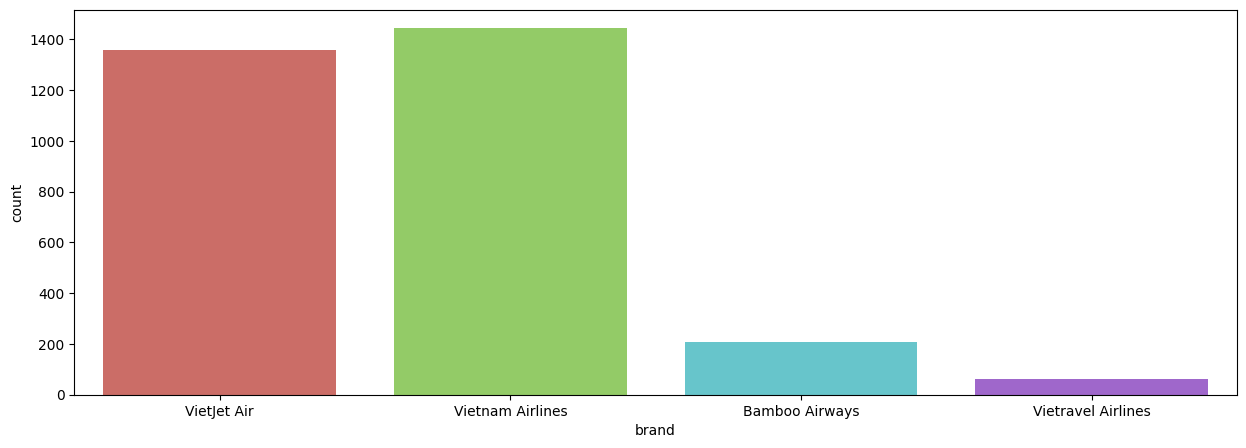

In [200]:
plt.figure(figsize=(15, 5))
sns.countplot(
    x='brand', 
    data=df1, 
    hue='brand', 
    palette='hls', 
    legend=False)
plt.show()

## PRICE & AIRLINES

In [201]:
df['price']

0        1245267
1        1224930
2        1535463
3        1567000
4        1567000
          ...   
45492    1505493
45493    1997001
45494    1379619
45495    1152900
45496    1675323
Name: price, Length: 45497, dtype: int64

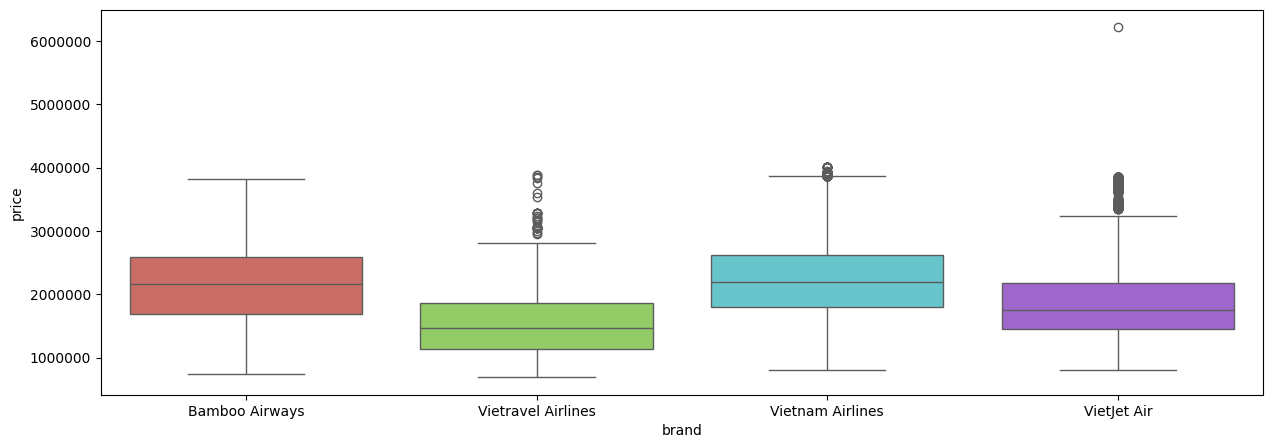

In [202]:
plt.figure(figsize=(15, 5))
sns.boxplot(
    x='brand', 
    y='price',
    data=df,
    hue='brand',
    palette='hls',
    legend=False
    )
plt.ticklabel_format(style='plain', axis='y')

PRICE: 
- max: VietNam
- min: Viettravel

UNUSUAL: Viettravel

## PRICE & TIME

<Axes: xlabel='end_hour', ylabel='price'>

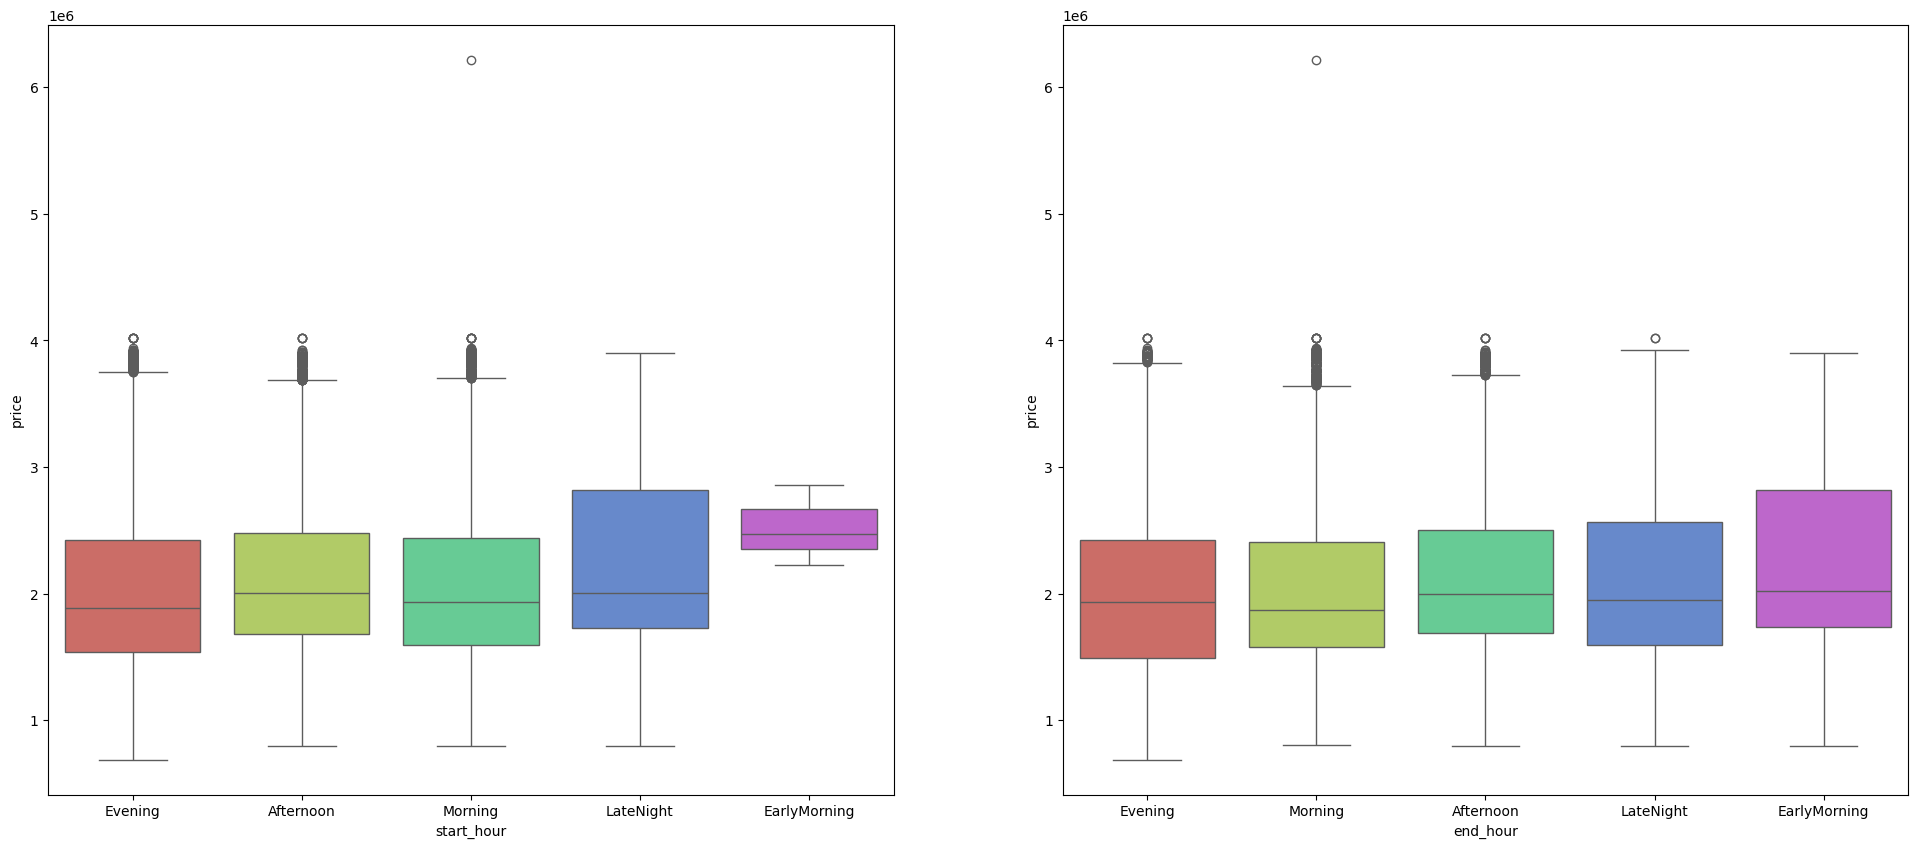

In [203]:
plt.figure(figsize=(24,10))

plt.subplot(1, 2, 1)
sns.boxplot(x='start_hour', y='price', data=df,
            hue='start_hour', palette='hls', legend=False)

plt.subplot(1, 2, 2)
sns.boxplot(x='end_hour', y='price', data=df,
            hue='end_hour', palette='hls', legend=False)

the price max is mostly the same for all category:
- biggest price range: LateNight (21h-24h)
- smallest price range + the most stable: Early Morning (0h-3h)

## PRICE & DESTINATION

<Axes: xlabel='destination', ylabel='price'>

) missing from font(s) DejaVu Sans.on\Python313\site-packages\IPython\core\events.py:82: UserWarning: Glyph 13 (
  func(*args, **kwargs)
) missing from font(s) DejaVu Sans.on\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


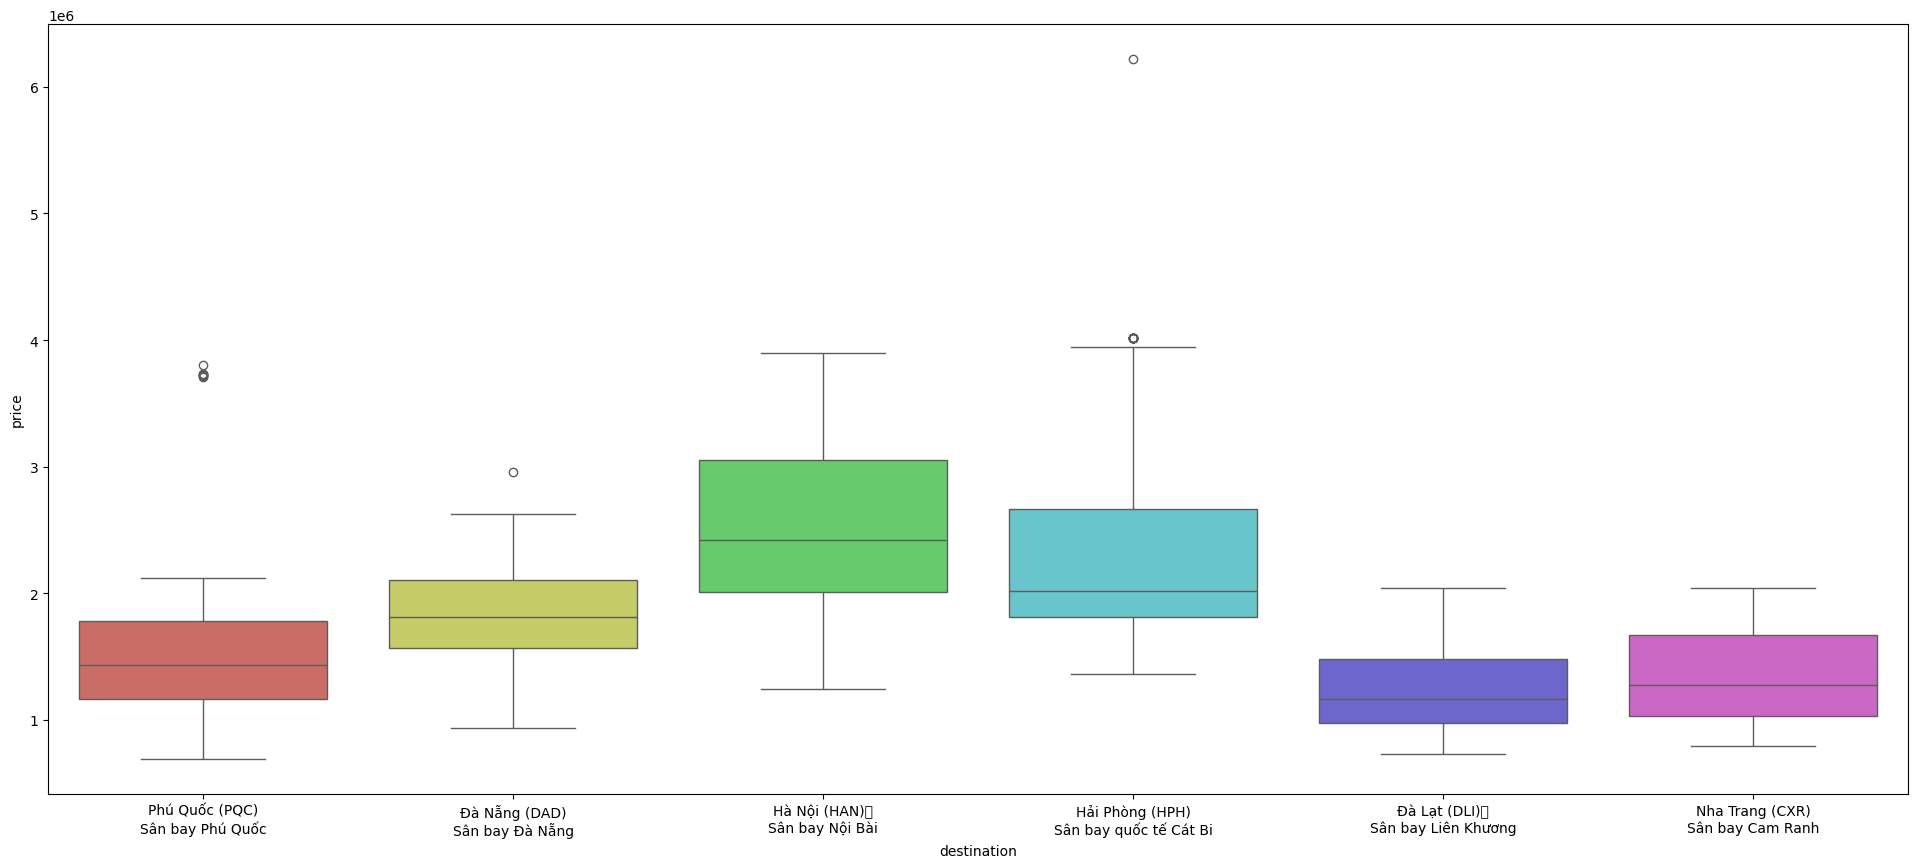

In [204]:
plt.figure(figsize=(24,10))

sns.boxplot(x='destination', y='price', data=df,
            hue='destination', palette='hls', legend=False)

In [205]:
df['destination'].unique()

array(['Phú Quốc (PQC)\nSân bay Phú Quốc',
       'Đà Nẵng (DAD)\nSân bay Đà Nẵng',
       'Hà Nội (HAN)\r\nSân bay Nội Bài',
       'Hải Phòng (HPH)\nSân bay quốc tế Cát Bi',
       'Đà Lạt (DLI)\r\nSân bay Liên Khương',
       'Nha Trang (CXR)\nSân bay Cam Ranh'], dtype=object)

In [206]:
df[df['price'] > 4000000].sort_values(by='price', ascending=False)

,id,brand,price,destination,hand_luggage,checked_baggage,start_hour,end_hour,trip_mins,is_holiday,days_left
36932,HPH0026,VietJet Air,6217970,Hải Phòng (HPH)\nSân bay quốc tế Cát Bi,7,0,Morning,Morning,120,0,1
39344,HPH0198,Vietnam Airlines,4017553,Hải Phòng (HPH)\nSân bay quốc tế Cát Bi,12,23,Morning,Morning,120,2,4
39390,HPH0204,Vietnam Airlines,4017553,Hải Phòng (HPH)\nSân bay quốc tế Cát Bi,10,23,Morning,Morning,120,0,3
39391,HPH0204,Vietnam Airlines,4017553,Hải Phòng (HPH)\nSân bay quốc tế Cát Bi,10,23,Morning,Morning,120,0,1
39452,HPH0211,Vietnam Airlines,4017553,Hải Phòng (HPH)\nSân bay quốc tế Cát Bi,12,23,Morning,Morning,120,0,2
39481,HPH0213,Vietnam Airlines,4017553,Hải Phòng (HPH)\nSân bay quốc tế Cát Bi,12,23,Morning,Morning,120,1,1
39491,HPH0214,Vietnam Airlines,4017553,Hải Phòng (HPH)\nSân bay quốc tế Cát Bi,12,23,Morning,Morning,120,1,1
39566,HPH0220,Vietnam Airlines,4017553,Hải Phòng (HPH)\nSân bay quốc tế Cát Bi,12,23,Afternoon,Afternoon,125,2,4
39567,HPH0220,Vietnam Airlines,4017553,Hải Phòng (HPH)\nSân bay quốc tế Cát Bi,12,23,Afternoon,Afternoon,125,2,2
39634,HPH0226,Vietnam Airlines,4017553,Hải Phòng (HPH)\nSân bay quốc tế Cát Bi,10,23,Afternoon,Afternoon,125,0,1


## PRICE & TRIP_TIME

In [207]:
df['trip_mins'].value_counts()

trip_mins
130    11287
125     8385
85      6251
60      4780
80      4622
120     3210
65      2561
55      2057
75       874
90       724
115      395
45       320
135       26
50         4
145        1
Name: count, dtype: int64

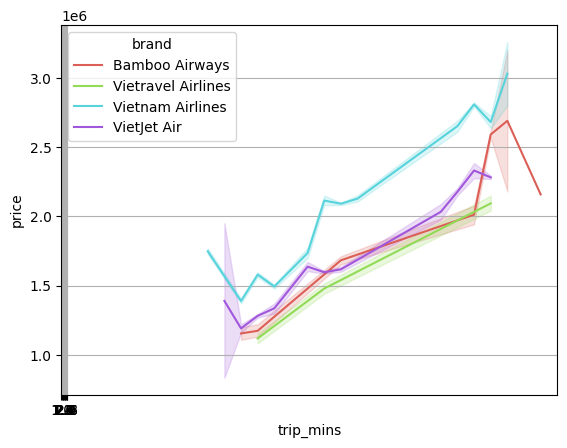

In [208]:
sns.lineplot(data=df, x='trip_mins', y='price', hue='brand', palette='hls')
plt.xticks(np.arange(1.0, 3.0, 0.2))
plt.grid(True)
plt.show()


## PRICE & DAYS_LEFT

In [209]:
df['days_left'].value_counts().sort_index(ascending=False)

days_left
20    1627
19    1717
18    1955
17    2030
16    2158
15    2355
14    2491
13    2443
12    2499
11    2537
10    2532
9     2501
8     2510
7     2396
6     2388
5     2406
4     2379
3     2282
2     2251
1     2040
Name: count, dtype: int64

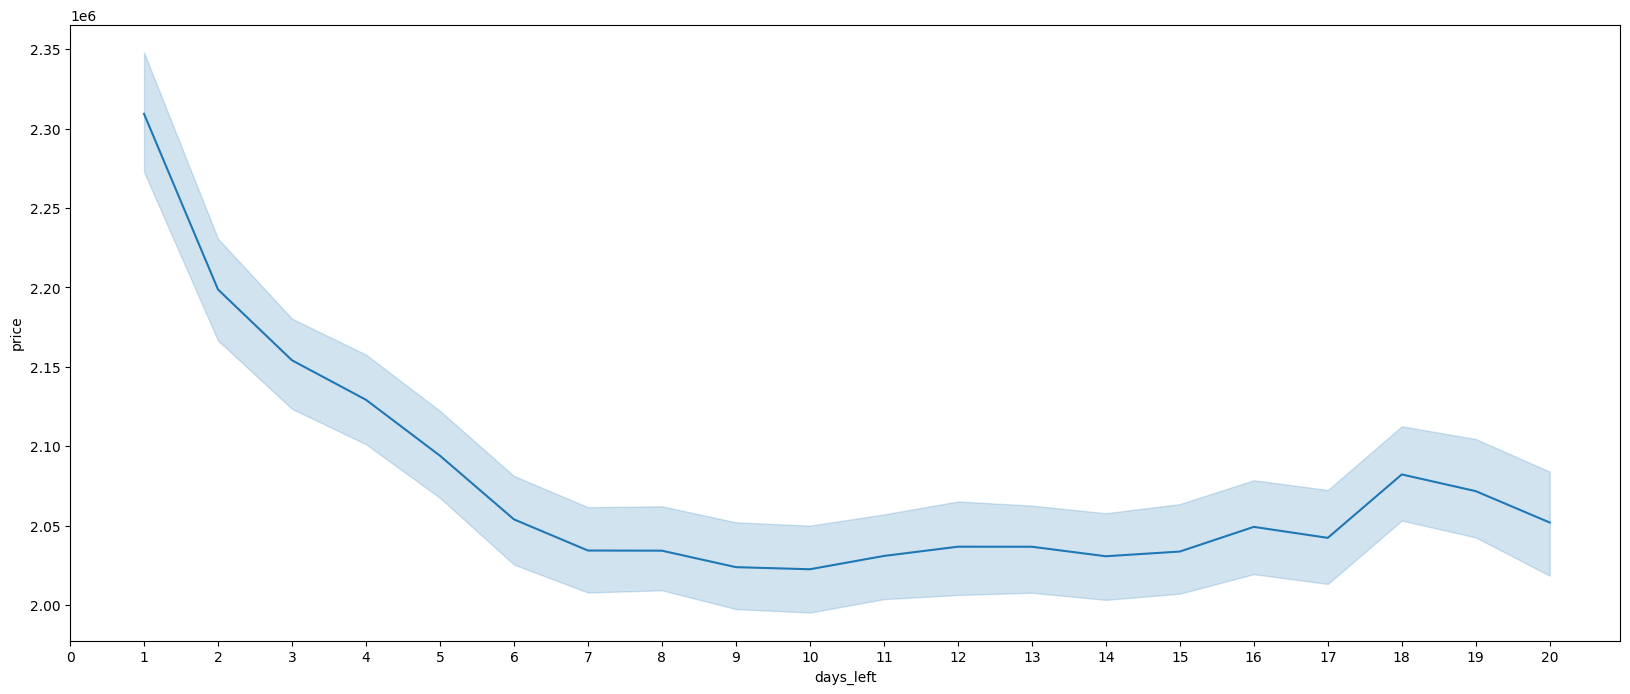

In [210]:
plt.figure(figsize=(20,8))
sns.lineplot(x='days_left', y='price', data=df)
# plt.gca().invert_xaxis()
plt.xticks(np.arange(20, -1, -1))
plt.show()

In [211]:
df['destination'].unique()

array(['Phú Quốc (PQC)\nSân bay Phú Quốc',
       'Đà Nẵng (DAD)\nSân bay Đà Nẵng',
       'Hà Nội (HAN)\r\nSân bay Nội Bài',
       'Hải Phòng (HPH)\nSân bay quốc tế Cát Bi',
       'Đà Lạt (DLI)\r\nSân bay Liên Khương',
       'Nha Trang (CXR)\nSân bay Cam Ranh'], dtype=object)

) missing from font(s) DejaVu Sans.pykernel_11184\3654046066.py:23: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.on\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


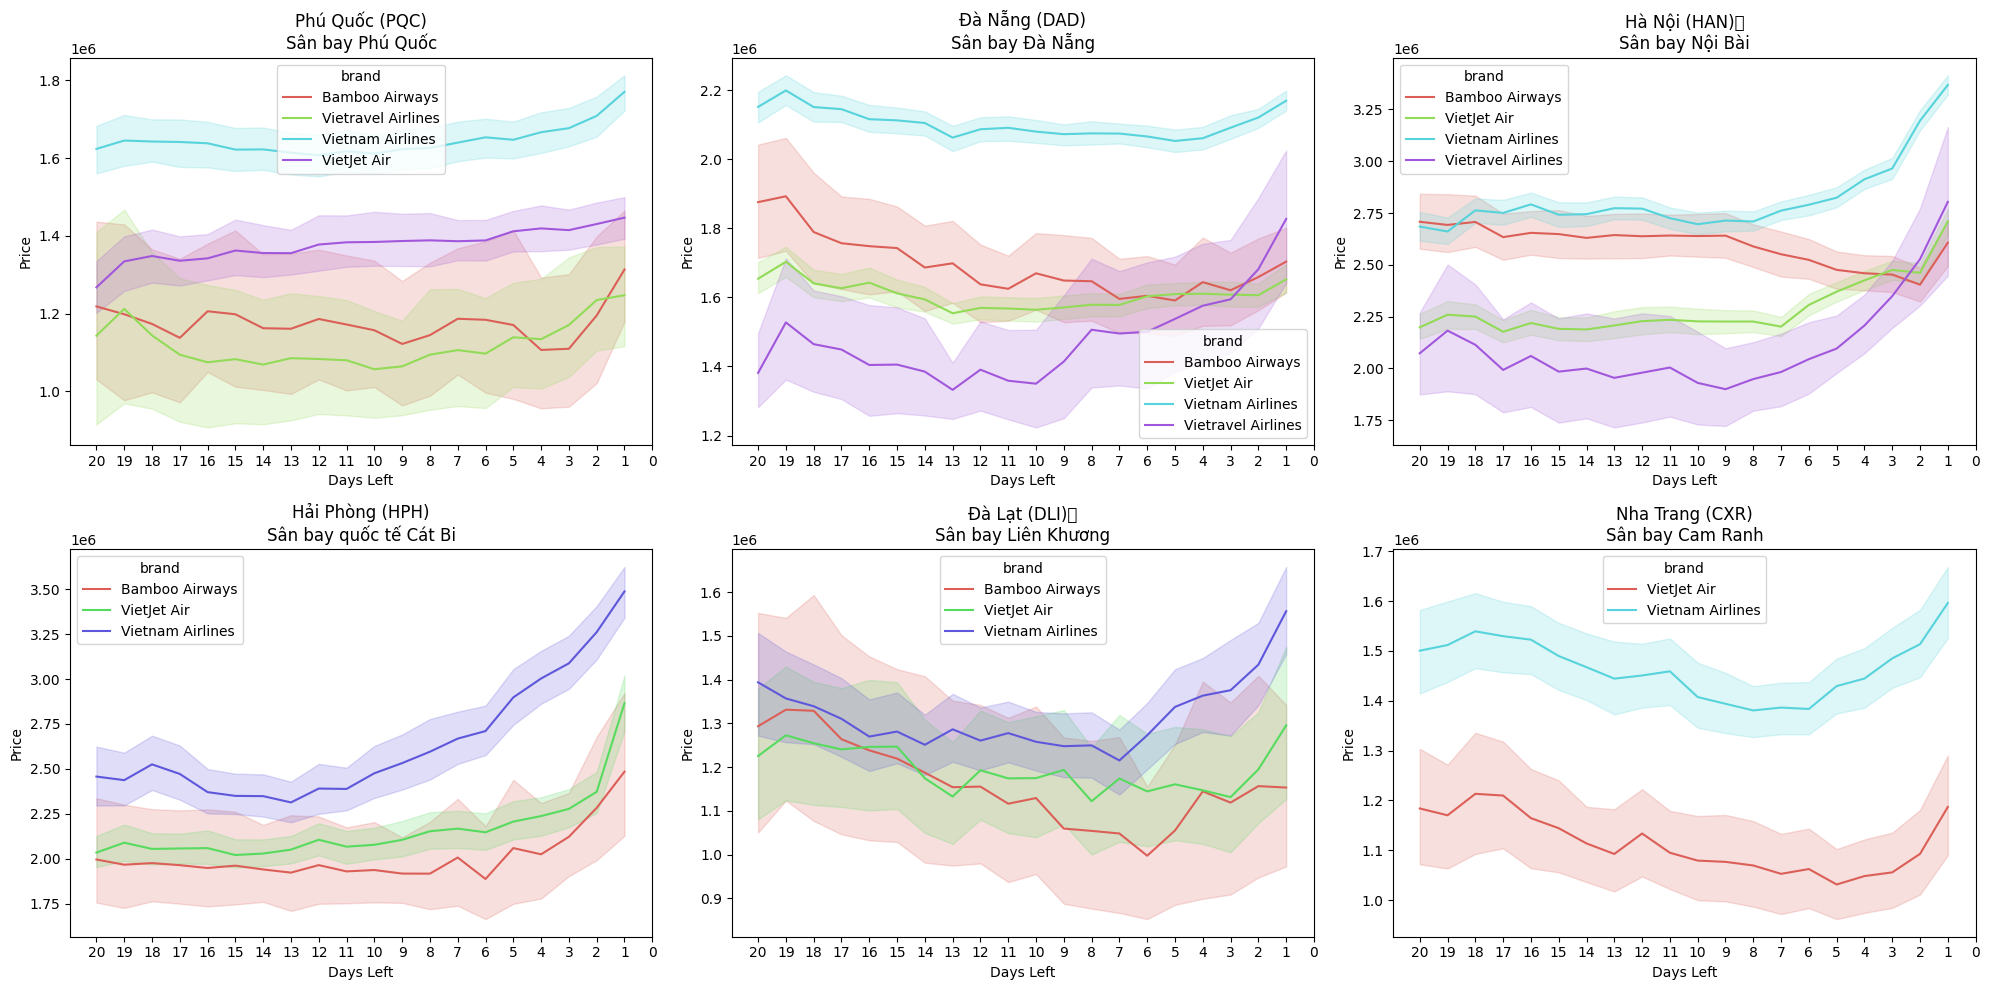

In [212]:
destinations = df['destination'].unique()[:6]  # Limit to 6

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Loop over destinations and plot
for i, place in enumerate(destinations):
    ax = axes[i]
    sns.lineplot(x='days_left', y='price',hue='brand', palette='hls', data=df[df['destination'] == place], ax=ax)
    ax.set_title(place)
    ax.set_xticks(np.arange(20, -1, -1))
    ax.set_xlabel('Days Left')
    ax.set_ylabel('Price')
    ax.invert_xaxis()  # Invert x-axis for each subplot

# Hide any unused subplots if there are fewer than 6 destinations
for j in range(len(destinations), 6):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

) missing from font(s) DejaVu Sans.pykernel_11184\4193708471.py:23: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.on\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


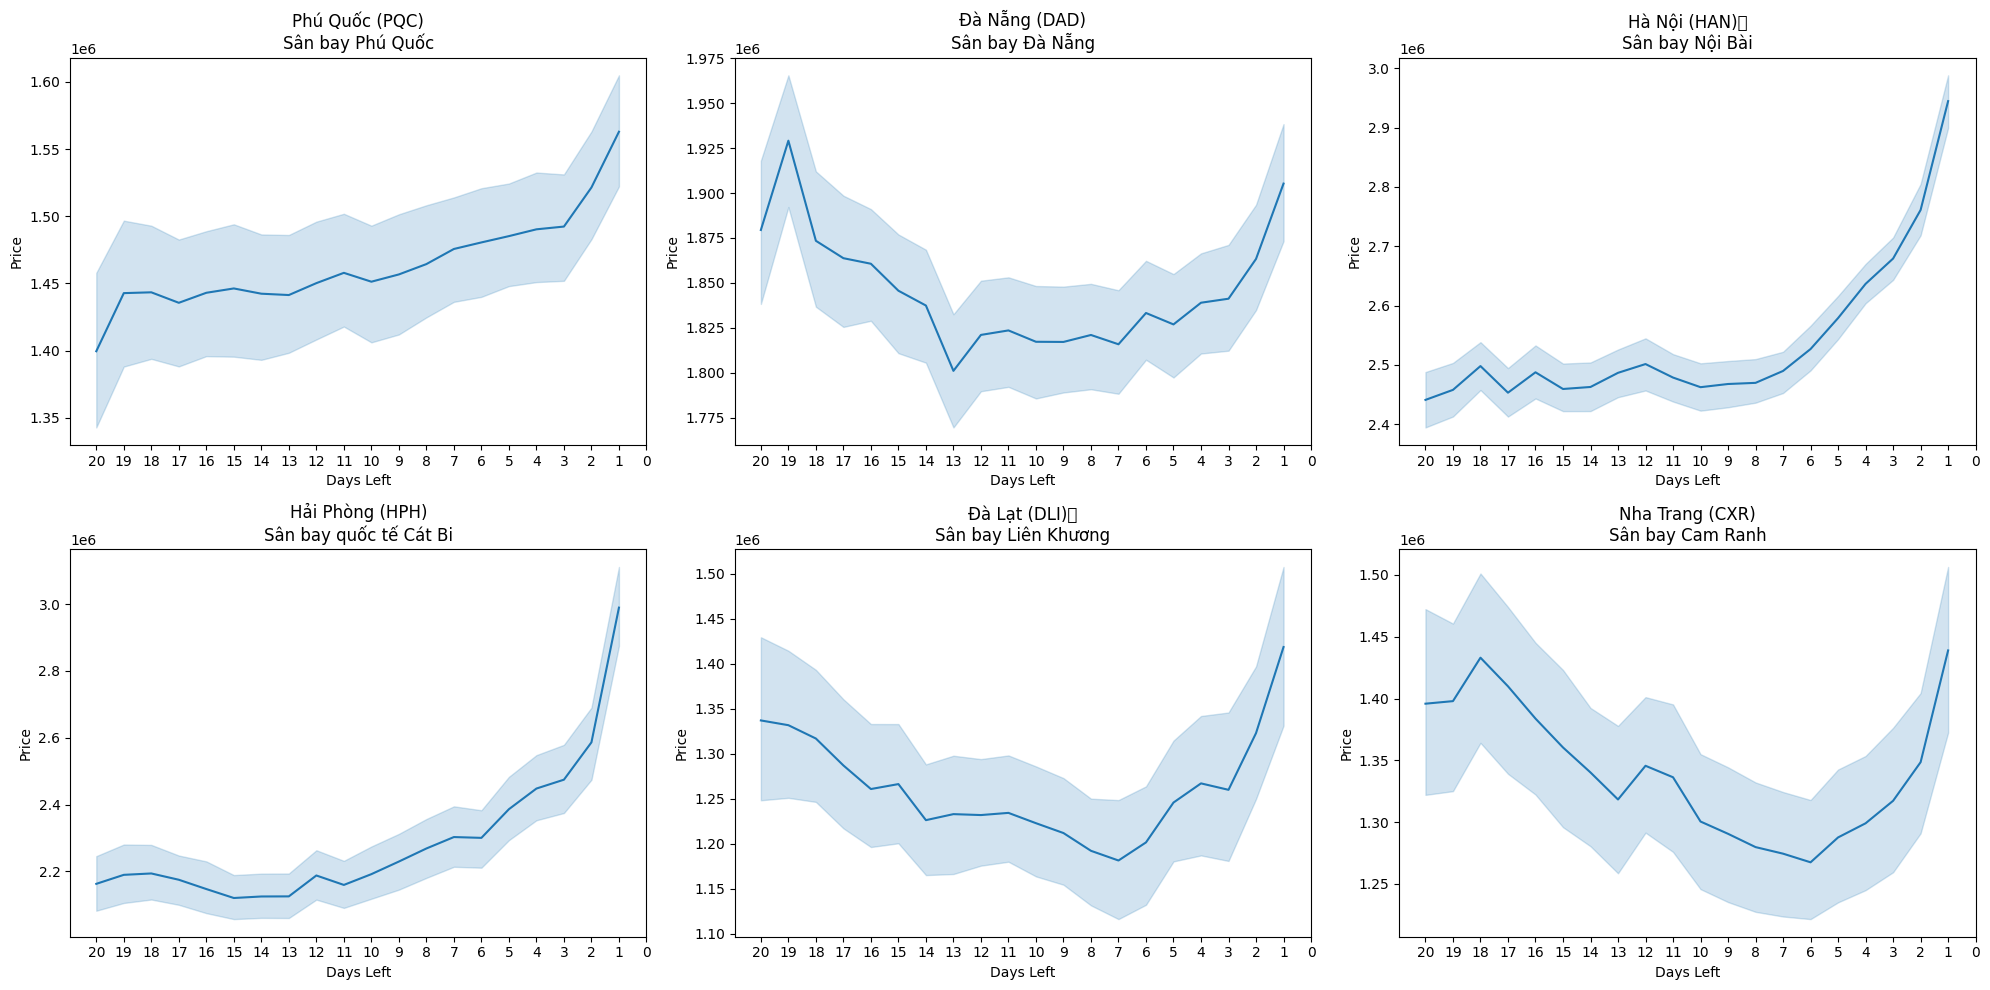

In [213]:
destinations = df['destination'].unique()[:6]  # Limit to 6

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Loop over destinations and plot
for i, place in enumerate(destinations):
    ax = axes[i]
    sns.lineplot(x='days_left', y='price', data=df[df['destination'] == place], ax=ax)
    ax.set_title(place)
    ax.set_xticks(np.arange(20, -1, -1))
    ax.set_xlabel('Days Left')
    ax.set_ylabel('Price')
    ax.invert_xaxis()  # Invert x-axis for each subplot

# Hide any unused subplots if there are fewer than 6 destinations
for j in range(len(destinations), 6):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

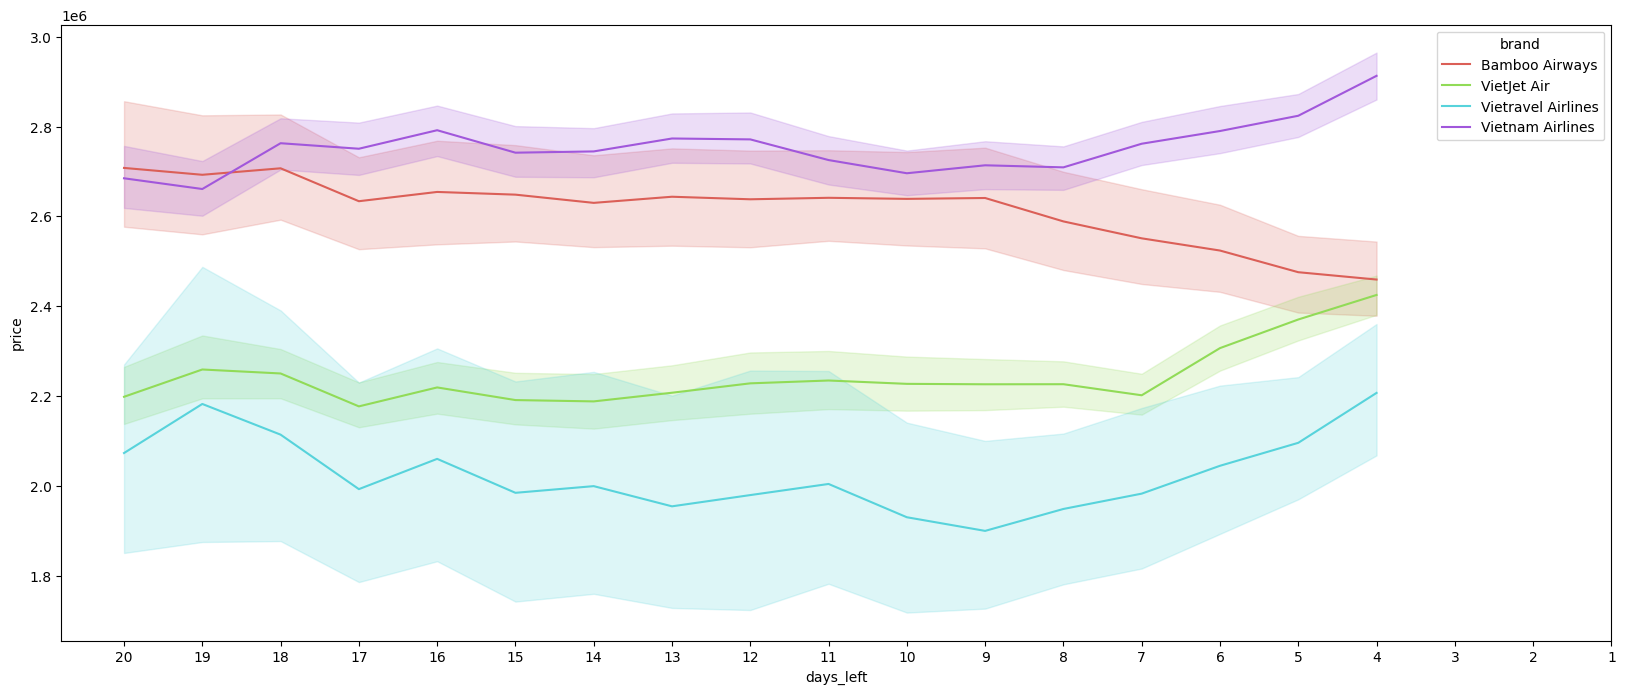

In [176]:
han_data = df[df['destination'] == 'Hà Nội (HAN)\r\nSân bay Nội Bài']

plt.figure(figsize=(20,8))
sns.lineplot(
    x='days_left', y='price', data=han_data,
    hue='brand', palette='hls')
plt.gca().invert_xaxis()
plt.xticks(np.arange(20, 0, -1))
plt.show()

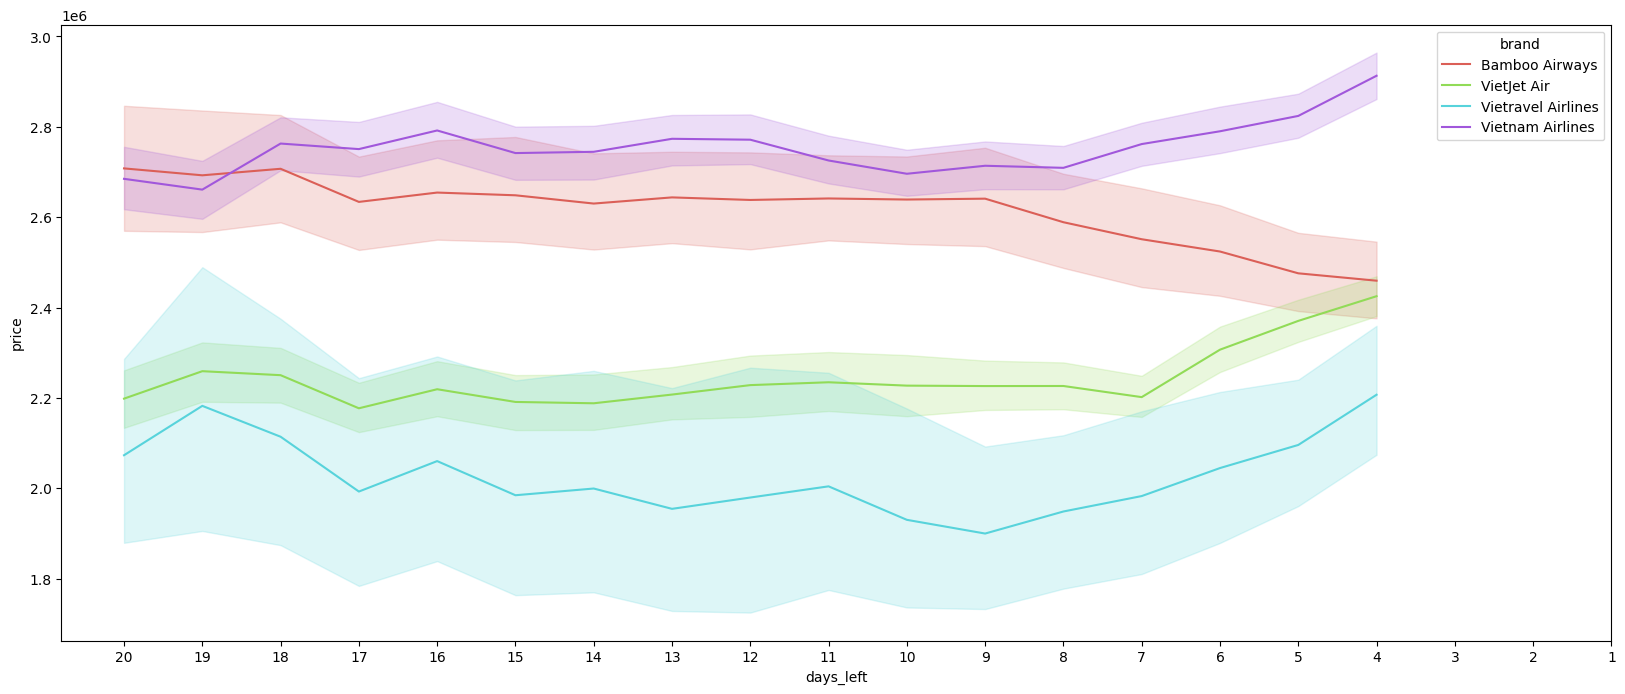

In [177]:
han_data = df[df['destination'] == 'Hà Nội (HAN)\r\nSân bay Nội Bài']

plt.figure(figsize=(20,8))
sns.lineplot(
    x='days_left', y='price', data=han_data,
    hue='brand', palette='hls')
plt.gca().invert_xaxis()
plt.xticks(np.arange(20, 0, -1))
plt.show()

# MODELING by kaggel

In [178]:
df = df.drop(columns=['id'], axis=1)

In [179]:
data = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38924 entries, 46 to 45496
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   brand            38924 non-null  object
 1   price            38924 non-null  int64 
 2   destination      38924 non-null  object
 3   hand_luggage     38924 non-null  int64 
 4   checked_baggage  38924 non-null  int64 
 5   start_hour       38924 non-null  object
 6   end_hour         38924 non-null  object
 7   trip_mins        38924 non-null  int64 
 8   is_holiday       38924 non-null  int64 
 9   days_left        38924 non-null  int64 
dtypes: int64(6), object(4)
memory usage: 3.3+ MB


In [180]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col])

In [181]:
from sklearn.model_selection import train_test_split
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((31139, 9), (7785, 9), (31139,), (7785,))

In [182]:
from sklearn.preprocessing import MinMaxScaler
mmscaler = MinMaxScaler(feature_range=(0, 1))
X_train = mmscaler.fit_transform(X_train)
X_test = mmscaler.transform(X_test)
X_train=pd.DataFrame(X_train)
X_test=pd.DataFrame(X_test)

In [183]:
a={'Model Name':[], 'Mean_Absolute_Error_MAE':[] ,'Adj_R_Square':[] ,'Root_Mean_Squared_Error_RMSE':[] ,'Mean_Absolute_Percentage_Error_MAPE':[] ,'Mean_Squared_Error_MSE':[] ,'Root_Mean_Squared_Log_Error_RMSLE':[] ,'R2_score':[]}
Results=pd.DataFrame(a)
Results.head()

,Model Name,Mean_Absolute_Error_MAE,Adj_R_Square,Root_Mean_Squared_Error_RMSE,Mean_Absolute_Percentage_Error_MAPE,Mean_Squared_Error_MSE,Root_Mean_Squared_Log_Error_RMSLE,R2_score


In [184]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn import linear_model
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics

In [185]:
modelmlg = LinearRegression()
modeldcr = DecisionTreeRegressor()
modelbag = BaggingRegressor()
modelrfr = RandomForestRegressor()
modelSVR = SVR()
modelXGR = xgb.XGBRegressor()
modelKNN = KNeighborsRegressor(n_neighbors=5)
modelETR = ExtraTreesRegressor()
modelRE=Ridge()
modelLO=linear_model.Lasso(alpha=0.1)

In [186]:
modelGBR = GradientBoostingRegressor(loss='squared_error', learning_rate=0.1, n_estimators=100, subsample=1.0,
                                     criterion='friedman_mse', min_samples_split=2, min_samples_leaf=1,
                                     min_weight_fraction_leaf=0.0, max_depth=3, min_impurity_decrease=0.0,
                                     init=None, random_state=None, max_features=None,
                                     alpha=0.9, verbose=0, max_leaf_nodes=None, warm_start=False,
                                     validation_fraction=0.1, n_iter_no_change=None, tol=0.0001, ccp_alpha=0.0)

# Evalution matrix for all the algorithms

MM = [modelmlg, modeldcr, modelrfr, modelKNN, modelETR, modelGBR, modelXGR, modelbag,modelRE,modelLO]

for models in MM:
    
    # Fit the model with train data
    
    models.fit(X_train, y_train)
    
    # Predict the model with test data

    y_pred = models.predict(X_test)
    
    # Print the model name
    
    print('Model Name: ', models)

    print('Mean Absolute Error (MAE):', round(metrics.mean_absolute_error(y_test, y_pred),3))  
    print('Mean Squared Error (MSE):', round(metrics.mean_squared_error(y_test, y_pred),3))  
    print('Root Mean Squared Error (RMSE):', round(np.sqrt(metrics.mean_squared_error(y_test, y_pred)),3))
    print('R2_score:', round(metrics.r2_score(y_test, y_pred),6))
    print('Root Mean Squared Log Error (RMSLE):', round(np.log(np.sqrt(metrics.mean_squared_error(y_test, y_pred))),3))
    
    # Define the function to calculate the MAPE - Mean Absolute Percentage Error

    def MAPE (y_test, y_pred):
        y_test, y_pred = np.array(y_test), np.array(y_pred)
        return np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    # Evaluation of MAPE 

    result = MAPE(y_test, y_pred)
    print('Mean Absolute Percentage Error (MAPE):', round(result, 2), '%')
    
    # Calculate Adjusted R squared values 
    r_squared = round(metrics.r2_score(y_test, y_pred),6)
    adjusted_r_squared = round(1 - (1-r_squared)*(len(y)-1)/(len(y)-X.shape[1]-1),6)
    print('Adj R Square: ', adjusted_r_squared)
    print('------------------------------------------------------------------------------------------------------------')
    #-------------------------------------------------------------------------------------------
    new_row = {'Model Name' : models,
               'Mean_Absolute_Error_MAE' : metrics.mean_absolute_error(y_test, y_pred),
               'Adj_R_Square' : adjusted_r_squared,
               'Root_Mean_Squared_Error_RMSE' : np.sqrt(metrics.mean_squared_error(y_test, y_pred)),
               'Mean_Absolute_Percentage_Error_MAPE' : result,
               'Mean_Squared_Error_MSE' : metrics.mean_squared_error(y_test, y_pred),
               'Root_Mean_Squared_Log_Error_RMSLE': np.log(np.sqrt(metrics.mean_squared_error(y_test, y_pred))),
               'R2_score' : metrics.r2_score(y_test, y_pred)}
    Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)
    #------------------------------------------------------------

Model Name:  LinearRegression()
Mean Absolute Error (MAE): 313913.481
Mean Squared Error (MSE): 163388696329.228
Root Mean Squared Error (RMSE): 404213.677
R2_score: 0.65383
Root Mean Squared Log Error (RMSLE): 12.91
Mean Absolute Percentage Error (MAPE): 16.03 %
Adj R Square:  0.65375
------------------------------------------------------------------------------------------------------------
Model Name:  DecisionTreeRegressor()
Mean Absolute Error (MAE): 248381.228
Mean Squared Error (MSE): 113709536308.474
Root Mean Squared Error (RMSE): 337208.446
R2_score: 0.759085
Root Mean Squared Log Error (RMSLE): 12.728
Mean Absolute Percentage Error (MAPE): 12.51 %
Adj R Square:  0.759029
------------------------------------------------------------------------------------------------------------
Model Name:  RandomForestRegressor()
Mean Absolute Error (MAE): 243161.556
Mean Squared Error (MSE): 106295473202.847
Root Mean Squared Error (RMSE): 326029.866
R2_score: 0.774793
Root Mean Squared Lo

In [187]:
Results

,Model Name,Mean_Absolute_Error_MAE,Adj_R_Square,Root_Mean_Squared_Error_RMSE,Mean_Absolute_Percentage_Error_MAPE,Mean_Squared_Error_MSE,Root_Mean_Squared_Log_Error_RMSLE,R2_score
0,LinearRegression(),313913.480995,0.653750,404213.676574,16.032075,1.633887e+11,12.909699,0.653830
1,DecisionTreeRegressor(),248381.227956,0.759029,337208.446378,12.514851,1.137095e+11,12.728457,0.759085
2,"(DecisionTreeRegressor(max_features=1.0, rando...",243161.556435,0.774741,326029.865508,12.239373,1.062955e+11,12.694744,0.774793
3,KNeighborsRegressor(),241235.889351,0.778746,323118.072520,12.107694,1.044053e+11,12.685773,0.778797
4,"(ExtraTreeRegressor(random_state=910914757), E...",247936.276943,0.761120,335742.603018,12.481535,1.127231e+11,12.724100,0.761175
5,([DecisionTreeRegressor(criterion='friedman_ms...,245598.807793,0.783624,319536.647706,12.490800,1.021037e+11,12.674627,0.783674
6,"XGBRegressor(base_score=None, booster=None, ca...",223922.968750,0.812332,297585.272754,11.237650,8.855699e+10,12.603456,0.812375
7,"(DecisionTreeRegressor(random_state=53636960),...",244573.696664,0.770938,328770.506181,12.312672,1.080900e+11,12.703115,0.770991
8,Ridge(),313901.097100,0.653758,404209.103596,16.031508,1.633850e+11,12.909688,0.653838
9,Lasso(alpha=0.1),313913.462154,0.653750,404213.661479,16.032072,1.633887e+11,12.909699,0.653830


In [188]:
models=['LinearRegression','DecisionTreeRegressor','RandomForestRegressor','KNeighborsRegressor','ExtraTreesRegressor','GradientBoostingRegressor','XGBRegressor','BaggingRegressor','Ridge Regression','Lasso Regression']
result=pd.DataFrame({'Model_Name':models})
result['Adj_R_Square']=Results['Adj_R_Square']
result['Mean_Absolute_Error_MAE']=Results['Mean_Absolute_Error_MAE']
result['Root_Mean_Squared_Error_RMSE']=Results['Root_Mean_Squared_Error_RMSE']
result['Mean_Absolute_Percentage_Error_MAPE']=Results['Mean_Absolute_Percentage_Error_MAPE']
result['Mean_Squared_Error_MSE']=Results['Mean_Squared_Error_MSE']
result['Root_Mean_Squared_Log_Error_RMSLE']=Results['Root_Mean_Squared_Log_Error_RMSLE']
result['R2_score']=Results['R2_score']
result=result.sort_values(by='Adj_R_Square',ascending=False).reset_index(drop=True)
result

,Model_Name,Adj_R_Square,Mean_Absolute_Error_MAE,Root_Mean_Squared_Error_RMSE,Mean_Absolute_Percentage_Error_MAPE,Mean_Squared_Error_MSE,Root_Mean_Squared_Log_Error_RMSLE,R2_score
0,XGBRegressor,0.812332,223922.968750,297585.272754,11.237650,8.855699e+10,12.603456,0.812375
1,GradientBoostingRegressor,0.783624,245598.807793,319536.647706,12.490800,1.021037e+11,12.674627,0.783674
2,KNeighborsRegressor,0.778746,241235.889351,323118.072520,12.107694,1.044053e+11,12.685773,0.778797
3,RandomForestRegressor,0.774741,243161.556435,326029.865508,12.239373,1.062955e+11,12.694744,0.774793
4,BaggingRegressor,0.770938,244573.696664,328770.506181,12.312672,1.080900e+11,12.703115,0.770991
5,ExtraTreesRegressor,0.761120,247936.276943,335742.603018,12.481535,1.127231e+11,12.724100,0.761175
6,DecisionTreeRegressor,0.759029,248381.227956,337208.446378,12.514851,1.137095e+11,12.728457,0.759085
7,Ridge Regression,0.653758,313901.097100,404209.103596,16.031508,1.633850e+11,12.909688,0.653838
8,LinearRegression,0.653750,313913.480995,404213.676574,16.032075,1.633887e+11,12.909699,0.653830
9,Lasso Regression,0.653750,313913.462154,404213.661479,16.032072,1.633887e+11,12.909699,0.653830


In [189]:
#Trainig the model with
modelXGR.fit(X_train, y_train)
    
# Predict the model with test data

y_pred = modelXGR.predict(X_test)
out=pd.DataFrame({'Price_actual':y_test,'Price_pred':y_pred})
result=df.merge(out,left_index=True,right_index=True)
result.sample(10)

,brand,price,destination,hand_luggage,checked_baggage,start_hour,end_hour,trip_mins,is_holiday,days_left,Price_actual,Price_pred
17598,2,2221014,0,12,23,3,4,125,1,9,2221014,2630338.500
10070,1,1411586,5,7,0,0,0,85,0,20,1411586,1724177.000
5487,1,1616571,5,7,0,0,0,80,0,5,1616571,1624759.625
25190,2,3501828,0,12,23,3,0,125,2,15,3501828,3564878.000
12580,2,1948050,5,12,23,0,0,85,1,20,1948050,2148705.500
6422,2,1807021,5,12,23,3,4,90,0,16,1807021,1815143.750
928,1,819000,3,7,0,3,4,60,0,11,819000,1075903.000
11687,1,1988339,5,7,0,0,0,80,2,13,1988339,1774874.875
1220,1,1161000,3,7,0,0,0,60,0,10,1161000,1324537.375
25036,2,3060944,0,12,23,0,0,125,2,13,3060944,3584356.500


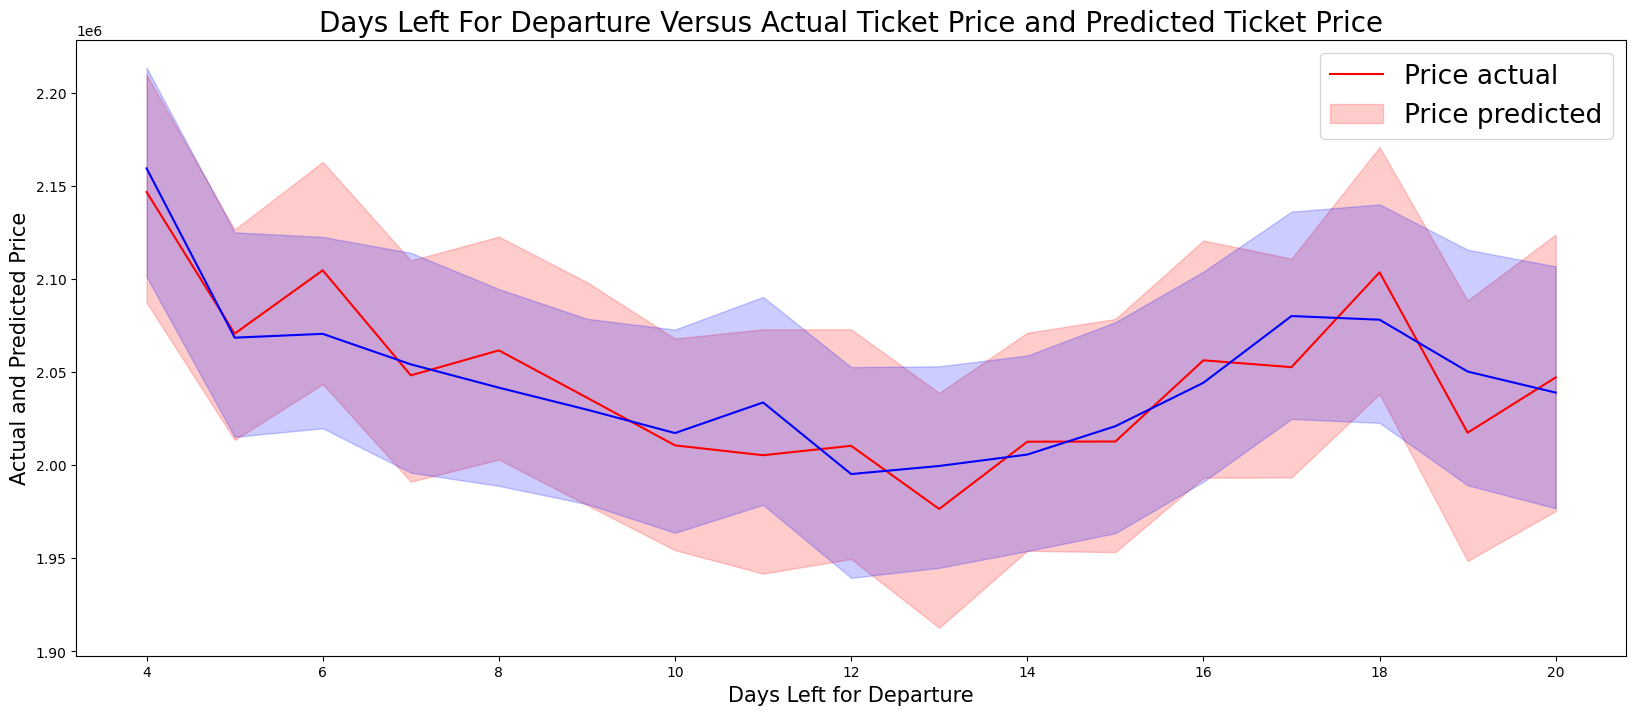

In [190]:
plt.figure(figsize=(20,8))
sns.lineplot(data=result,x='days_left',y='Price_actual',color='red')
sns.lineplot(data=result,x='days_left',y='Price_pred',color='blue')
plt.title('Days Left For Departure Versus Actual Ticket Price and Predicted Ticket Price',fontsize=20)
plt.legend(labels=['Price actual','Price predicted'],fontsize=19)
plt.xlabel('Days Left for Departure',fontsize=15)
plt.ylabel('Actual and Predicted Price',fontsize=15)
plt.show()

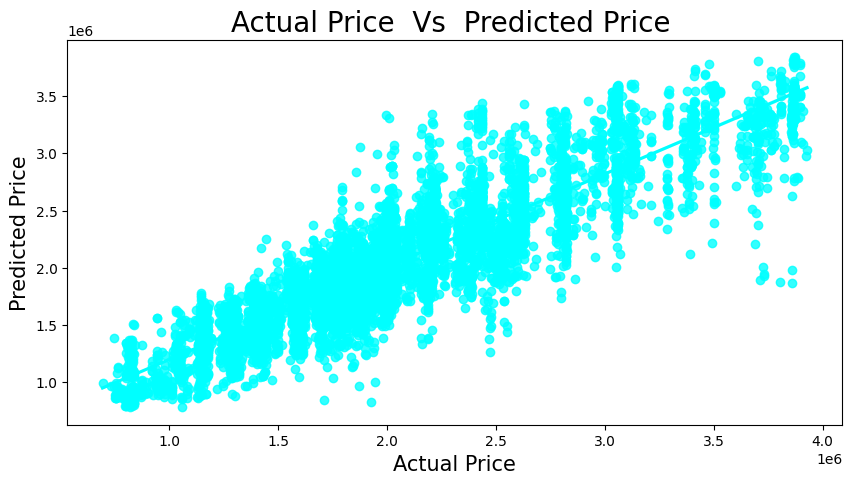

In [191]:
plt.figure(figsize=(10,5))
sns.regplot(x='Price_actual',y='Price_pred',data=result,color='cyan')
plt.title('Actual Price  Vs  Predicted Price ',fontsize=20)
plt.xlabel('Actual Price',fontsize=15)
plt.ylabel('Predicted Price',fontsize=15)
plt.show()

# MODELING

In [192]:
df = data.copy()
df.shape

(38924, 10)

In [193]:
df.head()

,brand,price,destination,hand_luggage,checked_baggage,start_hour,end_hour,trip_mins,is_holiday,days_left
46,Bamboo Airways,782244,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,60,0,4
47,Vietravel Airlines,767292,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,60,0,4
48,VietJet Air,817000,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Evening,Evening,65,0,4
49,Vietnam Airlines,1027746,Phú Quốc (PQC)\nSân bay Phú Quốc,12,0,Morning,Morning,55,0,4
50,VietJet Air,1037000,Phú Quốc (PQC)\nSân bay Phú Quốc,7,0,Morning,Morning,60,0,4


In [194]:
df_sorted = df.sort_values(by=['id', 'days_left'], ascending=[True, False])

df['min_price_so_far'] = df_sorted.groupby('id')['price'].cummin()
df['max_price_so_far'] = df_sorted.groupby('id')['price'].cummax()

df = df_sorted.sort_values(by=['id', 'days_left'], ascending=[True, True])

KeyError: 'id'

In [ ]:
df[df['id'] == 'HAN0555'][['id', 'days_left', 'price', 'min_price_so_far', 'max_price_so_far']].sort_values(by='days_left', ascending=False)

,id,days_left,price,min_price_so_far,max_price_so_far
4697,HAN0555,20,2970000,2970000,2970000
5320,HAN0555,19,2957140,2957140,2970000
5981,HAN0555,18,3081278,2957140,3081278
6685,HAN0555,17,3090255,2957140,3090255
7366,HAN0555,16,3101228,2957140,3101228
7984,HAN0555,15,3069308,2957140,3101228
8866,HAN0555,14,3364568,2957140,3364568
9780,HAN0555,13,3412448,2957140,3412448
10758,HAN0555,12,3411450,2957140,3412448
11796,HAN0555,11,3398483,2957140,3412448


    STEP 1: load raw data
    """
    load_for_classification_for_Specific()
    load_for_classification_for_General()

    """

In [ ]:

    """
    Load the data for classification
    :param dataset: dataset name('Specific' or 'General')
    :return: X_train, y_train, X_test, y_test
    """
    isOneOptimalState = False
    # Construct the input data
    dim = routes.__len__() + 4
    X_train = np.empty(shape=(0, dim))
    y_train = np.empty(shape=(0,1))
    y_train_price = np.empty(shape=(0,1))
    X_test = np.empty(shape=(0,dim))
    y_test = np.empty(shape=(0,1))
    y_test_price = np.empty(shape=(0,1))

    for filePrefix in routes:
        datas = load_data_with_prefix_and_dataset(filePrefix, dataset)
        for data in datas:
            print "Construct route {}, State {}, departureDate {}...".format(filePrefix, data["State"], data["Date"])
            x_i = []
            # feature 1: flight number -> dummy variables
            for i in range(len(routes)):
                """
                !!!need to change!
                """
                if i == routes.index(filePrefix):
                    x_i.append(1)
                else:
                    x_i.append(0)

            # feature 2: departure date interval from "20151109", because the first observed date is 20151109
            departureDate = data["Date"]
            """
            !!!maybe need to change the first observed date
            """
            departureDateGap = util.days_between(departureDate, "20151109")
            x_i.append(departureDateGap)

            # feature 3: observed days before departure date
            state = data["State"]
            x_i.append(state)

            # feature 4: minimum price before the observed date
            minimumPreviousPrice = getMinimumPreviousPrice(data["Date"], state, datas)
            x_i.append(minimumPreviousPrice)

            # feature 5: maximum price before the observed date
            maximumPreviousPrice = getMaximumPreviousPrice(data["Date"], state, datas)
            x_i.append(maximumPreviousPrice)

            # output
            y_i = [0]
            specificDatas = []
            specificDatas = [data2 for data2 in datas if data2["Date"]==departureDate]

            # if isOneOptimalState:
            #     # Method 1: only 1 entry is buy
            #     optimalState = getOptimalState(specificDatas)
            #     if data["State"] == optimalState:
            #        y_i = [1]
            # else:
            #     # Method 2: multiple entries can be buy
            #     minPrice = getMinimumPrice(specificDatas)
            #     if util.getPrice(data["MinimumPrice"]) == minPrice:
            #         y_i = [1]

            #Method 2: multiple entries can be buy
            minPrice = getMinimumPrice(specificDatas)
            if util.getPrice(data["MinimumPrice"]) == minPrice:
                y_i = [1]


            # keep price info
            y_price = [util.getPrice(data["MinimumPrice"])]

            if int(departureDate) < 20160229 and int(departureDate) >= 20151129: # choose date between "20151129-20160229(20160115)" as training data
                X_train = np.concatenate((X_train, [x_i]), axis=0)
                y_train = np.concatenate((y_train, [y_i]), axis=0)
                y_train_price = np.concatenate((y_train_price, [y_price]), axis=0)
            elif int(departureDate) < 20160508 and int(departureDate) >= 20160229: # choose date before "20160508(20160220)" as test data
                X_test = np.concatenate((X_test, [x_i]), axis=0)
                y_test = np.concatenate((y_test, [y_i]), axis=0)
                y_test_price = np.concatenate((y_test_price, [y_price]), axis=0)
            else:
                pass

            # X_train = np.concatenate((X_train, [x_i]), axis=0)
            # y_train = np.concatenate((y_train, [y_i]), axis=0)
            # y_train_price = np.concatenate((y_train_price, [y_price]), axis=0)

        # end of for datas
    # end of for routes


    """
    remove duplicate rows for train
    """
    tmp_train = np.concatenate((X_train, y_train, y_train_price), axis=1)
    new_array = [tuple(row) for row in tmp_train]
    tmp_train = np.unique(new_array)

    # get the result
    X_train = tmp_train[:, 0:12]
    y_train = tmp_train[:, 12]
    y_train_price = tmp_train[:, 13]

    """
    remove duplicate rows for test
    """
    tmp_test = np.concatenate((X_test, y_test, y_test_price), axis=1)
    new_array = [tuple(row) for row in tmp_test]
    tmp_test = np.unique(new_array)

    # get the result
    X_test = tmp_test[:, 0:12]
    y_test = tmp_test[:, 12]
    y_test_price = tmp_test[:, 13]

    # save the result
    np.save('inputSpecificRaw/X_train', X_train)
    np.save('inputSpecificRaw/y_train', y_train)
    np.save('inputSpecificRaw/y_train_price', y_train_price)
    np.save('inputSpecificRaw/X_test', X_test)
    np.save('inputSpecificRaw/y_test', y_test)
    np.save('inputSpecificRaw/y_test_price', y_test_price)

    return X_train, y_train, X_test, y_test

# step 1. The main data load function - for classification for the general dataset
"""
def load_for_classification_for_General(dataset="General", routes=routes_general):
    """
    Load the data for classification
    :param dataset: dataset name('Specific' or 'General')
    :return: X_train, y_train, X_test, y_test
    """
    isOneOptimalState = False
    # Construct the input data
    dim = routes.__len__() + 4
    X_train = np.empty(shape=(0, dim))
    y_train = np.empty(shape=(0,1))
    y_train_price = np.empty(shape=(0,1))

    for filePrefix in routes:
        print filePrefix
        datas = load_data_with_prefix_and_dataset(filePrefix, dataset)
        for data in datas:
            print "Construct route {}, State {}, departureDate {}...".format(filePrefix, data["State"], data["Date"])
            x_i = []
            # feature 1: flight number -> dummy variables
            for i in range(len(routes)):
                """
                !!!need to change!
                """
                if i == routes.index(filePrefix):
                    x_i.append(1)
                else:
                    x_i.append(0)

            # feature 2: departure date interval from "20151109", because the first observed date is 20151109
            departureDate = data["Date"]
            """
            !!!maybe need to change the first observed date
            """
            departureDateGap = util.days_between(departureDate, "20151109")
            x_i.append(departureDateGap)

            # feature 3: observed days before departure date
            state = data["State"]
            x_i.append(state)

            # feature 4: minimum price before the observed date
            minimumPreviousPrice = getMinimumPreviousPrice(data["Date"], state, datas)
            x_i.append(minimumPreviousPrice)

            # feature 5: maximum price before the observed date
            maximumPreviousPrice = getMaximumPreviousPrice(data["Date"], state, datas)
            x_i.append(maximumPreviousPrice)

            # output
            y_i = [0]
            specificDatas = []
            specificDatas = [data2 for data2 in datas if data2["Date"]==departureDate]

            minPrice = getMinimumPrice(specificDatas)
            if util.getPrice(data["MinimumPrice"]) == minPrice:
                y_i = [1]


            # keep price info
            y_price = [util.getPrice(data["MinimumPrice"])]

            X_train = np.concatenate((X_train, [x_i]), axis=0)
            y_train = np.concatenate((y_train, [y_i]), axis=0)
            y_train_price = np.concatenate((y_train_price, [y_price]), axis=0)

        # end of for datas
    # end of for routes


    """
    remove duplicate rows
    """
    tmp = np.concatenate((X_train, y_train, y_train_price), axis=1)
    new_array = [tuple(row) for row in tmp]
    tmp = np.unique(new_array)

    # # get the result
    # X_train = tmp[:, 0:16]
    # y_train = tmp[:, 16]
    # y_train_price = tmp[:, 17]

    # save the result
    np.save('inputGeneralRaw/X_train', X_train)
    np.save('inputGeneralRaw/y_train', y_train)
    np.save('inputGeneralRaw/y_train_price', y_train_price)
    np.save('inputGeneralRaw/tmp', tmp)

    return X_train, y_train, y_train_price


    STEP 2: get the data for the classification problem
    """
    priceNormalize_for_Specific()
    priceNormalize_for_General()

    """

    STEP 3: get the data for the regression problem
    """
    getRegressionOutput_for_SpecificTrain()
    getRegressionOutput_for_SpecificTest()